In [ ]:
#1 Importing Libraries and dataset

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/ML_Mini-Project/Student Academic & Placement Information.xlsx"

df1 = pd.read_excel(file_path)

df = df1

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Timestamp,Email Address,Full Name,PRN,Department,CGPA,Internship Experience,Internship duration :,Coding platforms you practice :,Total number of questions solved :,Extra Curricular Score (Rate yourself from 0-10),Communication and soft skills (Rate yourself from 0-10),Projects Completed:,Placement Status / Internship Status :,"If yes, Enter company/firm name and your role:"
0,2026-08-02 22:06:44.841,pradnyawakode2712@gmail.com,Pradnya Wakode,123B1B231,Computer Engineering,7.97,Yes (unpaid),10 weeks,"LeetCode, HackerRank",150,8.0,8,2,No,Na
1,2026-08-02 22:07:33.204,sahil.kasture24@pccoepune.org,Sahil Suresh Kasture,124B2B039,Computer Engineering,7.29,Yes (unpaid),1 Month,"LeetCode, HackerRank",61,7.0,6,5+,No,NaN
2,2026-08-02 22:10:11.522,suldhanashree13@gmail.com,Dhanashree Sikandar Sul,123B1B273,Computer Engineering,8.41,Yes (unpaid),1 Month,"LeetCode, CodeChef, HackerRank, GeeksforGeeks",500+,9.0,7,5+,No,NaN
3,2026-08-02 22:10:37.362,vivek.painjane23@pccoepune.org,Vivek Painjane,123B1B280,Computer Engineering,6.40,No,NaN,HackerRank,15,7.0,7,4,No,NaN
4,2026-08-02 22:11:33.144,sejal.jain24@pccoepune.org,Sejal Sanjay Jain,124B2B038,Computer Engineering,8.30,No,NaN,LeetCode,200,7.0,8,4,No,NaN


### Point 2: Convert Internship Duration to Weeks
**Theory:** Data standardization. Time-based features often arrive in mixed units (e.g., some students write 'months', others 'weeks') via free-form text. Unifying the unit ensures the machine learning model can accurately interpret the numerical scale of the feature.

**Observation:** Converts qualitative entries like '1 month' into comparable numerical values (e.g., 4 weeks), eliminating data sparsity and allowing the model to accurately weigh internship duration.

In [ ]:
# 2. Convert Internship Duration to Weeks
import re

def convert_to_weeks(duration):
    if pd.isna(duration) or duration == 'Na' or duration == 0 or duration == '0':
        return 0

    # If it's already a number (e.g. cell was run twice), just return it
    if isinstance(duration, (int, float)):
        return int(duration)

    duration_str = str(duration).strip().lower()

    # Extract the number
    match = re.search(r'(\d+)', duration_str)
    if not match:
        return 0

    num = int(match.group(1))

    # Convert based on unit (assuming 4 weeks per month)
    if 'month' in duration_str:
        return num * 4
    elif 'week' in duration_str:
        return num

    # Fallback: if it's just a number with no unit, assume it was already converted
    return num

# Apply logic (handling potential re-runs gracefully)
if 'Internship duration :' in df.columns:
    df['Internship duration :'] = df['Internship duration :'].apply(convert_to_weeks)
    df.rename(columns={'Internship duration :': 'Internship Duration (weeks) :'}, inplace=True)
elif 'Internship Duration (weeks) :' in df.columns:
    df['Internship Duration (weeks) :'] = df['Internship Duration (weeks) :'].apply(convert_to_weeks)

print("Unique durations in weeks:", df['Internship Duration (weeks) :'].unique())


Unique durations in weeks: [10  4  0 16 24 12  6 48 20  2  8]


### Point 3: Convert Total Questions Solved to Numerical
**Theory:** String Parsing & Numerical Extraction. Real-world survey data often contains extra characters (like '500+'). Machine learning models require pure numerical vectors to perform mathematical operations.

**Observation:** Strips away non-numeric characters, transforming a categorical-like string feature into a continuous numerical one, allowing algorithms to capture the true magnitude of a student's coding practice.

In [ ]:
# 3. Convert Total number of questions solved to numerical
import re

def convert_questions_solved(val):
    if pd.isna(val) or val == 'Na':
        return 0
    if isinstance(val, (int, float)):
        return int(val)

    val_str = str(val)
    # Extract the first sequence of digits (handles things like '500+', '400')
    match = re.search(r'(\d+)', val_str)
    if match:
        return int(match.group(1))
    return 0

# The column actually has a trailing space in the Excel file
col_q = 'Total number of questions solved : '
if col_q in df.columns:
    df[col_q] = df[col_q].apply(convert_questions_solved)
    # Let's also remove the trailing space to make it cleaner
    df.rename(columns={col_q: 'Total number of questions solved :'}, inplace=True)
elif 'Total number of questions solved :' in df.columns:
    # Handle re-runs
    df['Total number of questions solved :'] = df['Total number of questions solved :'].apply(convert_questions_solved)

print("Unique questions solved:", df['Total number of questions solved :'].unique())


Unique questions solved: [ 150   61  500   15  200  350 1000  250    0  185   50  120   80  600
  400   10  300  800  700   18  245  302   25  115   95  320  145  510
  210  680  275  340  190  220  470  125  360   65  290  410  155   35
  240  305  720  285  170  380   55  430  260  180   75  230  315   90
  850  205  390   60  330  480  100   45  520  135  160  295  450  310
   40  375   70  640  175  280  110  355   85  550   30  270  395  105
  225  780   20  420  235  490  365  440  530]


### Point 4: Convert Projects Completed to Numerical
**Theory:** Data Cleaning. Similar to questions solved, handling string artifacts to retrieve pure integer values.

**Observation:** Ensures the feature is treated as numerical by the model, preserving the linear relationship of project experience (i.e., 4 projects is twice as many as 2).

In [ ]:
# 4. Convert Projects Completed to numerical
import re

def convert_projects(val):
    if pd.isna(val) or val == 'Na':
        return 0
    if isinstance(val, (int, float)):
        return int(val)

    val_str = str(val)
    match = re.search(r'(\d+)', val_str)
    if match:
        return int(match.group(1))
    return 0

# This column also has a trailing space in the Excel file
col_p = 'Projects Completed: '
if col_p in df.columns:
    df[col_p] = df[col_p].apply(convert_projects)
    # Remove trailing space from the name
    df.rename(columns={col_p: 'Projects Completed:'}, inplace=True)
elif 'Projects Completed:' in df.columns:
    # Handle re-runs
    df['Projects Completed:'] = df['Projects Completed:'].apply(convert_projects)

print("Unique projects completed:", df['Projects Completed:'].unique())


Unique projects completed: [2 5 4 3 1]


### Point 5: Parse Coding Platforms
**Theory:** Multi-label Binarization. When one column contains multiple comma-separated answers, splitting it into individual binary columns (Yes/No) gives independent mathematical weights to each specific category.

**Observation:** Transforms a single complex string into four distinct, actionable features. This enables the model to learn the specific impact of each platform (e.g., does practicing on LeetCode yield a higher placement chance than HackerRank?).

In [ ]:
# 5. Parse Coding Platforms into separate columns
col_platforms = 'Coding platforms you practice : '

platforms = ['LeetCode', 'HackerRank', 'CodeChef', 'CodeForces']

def check_platform(row_val, platform_name):
    if pd.isna(row_val):
        return 'No'
    # Check if the platform name exists in the student's entry (case-insensitive)
    if platform_name.lower() in str(row_val).lower():
        return 'Yes'
    return 'No'

if col_platforms in df.columns:
    # 1. Create/Update the columns
    for p in platforms:
        df[p] = df[col_platforms].apply(lambda x: check_platform(x, p))

    # 2. Shift them to be right next to the original column
    col_idx = df.columns.get_loc(col_platforms)

    for i, p in enumerate(platforms):
        col_data = df.pop(p)
        df.insert(col_idx + 1 + i, p, col_data)

    # 3. Drop the original column
    df.drop(columns=[col_platforms], inplace=True)
    print("Parsed Platforms, shifted columns, and dropped original successfully!")

    # Show a small sample of the new columns
    print(df[platforms].head(10))
else:
    print(f"Column '{col_platforms}' not found in DataFrame (perhaps already dropped).")


Parsed Platforms, shifted columns, and dropped original successfully!
  LeetCode HackerRank CodeChef CodeForces
0      Yes        Yes       No         No
1      Yes        Yes       No         No
2      Yes        Yes      Yes         No
3       No        Yes       No         No
4      Yes         No       No         No
5      Yes         No      Yes         No
6      Yes        Yes      Yes         No
7      Yes        Yes      Yes         No
8       No         No       No         No
9      Yes         No       No         No


### Point 6: Clean Company/Firm Name Column
**Theory:** Missing Value Imputation and Standardization. Datasets often contain multiple distinct string representations of a null value (e.g., 'NA', 'None', '0', 'No', or just blank).

**Observation:** Collapses all non-internship responses into a uniform 'No'. This reduces noise and prevents the model from learning false, random patterns from the different ways people typed 'nothing'.

In [ ]:
# 6. Clean Company/Firm Name Column
col_company = 'If yes, Enter company/firm name and your role:'

def clean_company_name(val):
    if pd.isna(val):
        return 'No'

    val_str = str(val).strip()
    # Handle various forms of 'No', 'NA', 'None' etc.
    if val_str.lower() in ['no', 'na', 'n/a', 'none', '0']:
        return 'No'

    return val_str

if col_company in df.columns:
    df[col_company] = df[col_company].apply(clean_company_name)


In [ ]:
# 7. Drop Timestamp, Email Address, Full Name, PRN Column
if 'Timestamp' in df.columns:
    df.drop(columns=['Timestamp'], inplace=True)

if 'Email Address' in df.columns:
    df.drop(columns=['Email Address'], inplace=True)

if 'Full Name' in df.columns:
    df.drop(columns=['Full Name'], inplace=True)

if 'PRN ' in df.columns:
    df.drop(columns=['PRN '], inplace=True)

### Point 8: Detect and Treat Outliers
**Theory:** Outlier Treatment (IQR Method). Extreme values can severely skew distance-based models and regression slopes. Capping via the Interquartile Range (IQR) mitigates the impact of extreme outliers without losing valuable training rows (which is critical in small datasets).

**Observation:** Caps values falling outside the 1.5 * IQR boundaries. This prevents a single extreme student (e.g., claiming 5000 questions solved) from dominating the model's weights and skewing the predictions for everyone else.

In [ ]:
# 8. Detect and Treat Outliers (using IQR clipping)
def treat_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Check how many outliers exist
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    if len(outliers) > 0:
        print(f"Capping {len(outliers)} outliers in '{column}'")
        # Clip the outliers to the lower/upper bounds
        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

# We only want to apply this to numerical columns.
# By now, our custom cells have converted columns like Internship Duration and Projects to numeric.
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    treat_outliers_iqr(df, col)

print("Outlier treatment completed successfully!")


Capping 1 outliers in 'Internship Duration (weeks) :'
Capping 4 outliers in 'Total number of questions solved :'
Capping 11 outliers in 'Extra Curricular Score (Rate yourself from 0-10)'
Outlier treatment completed successfully!


### Point 9: Correlation Matrix Analysis
**Theory:** Exploratory Data Analysis (EDA) & Feature Collinearity. A correlation matrix visualizes the linear relationships (Pearson correlation) between all numerical variables.

**Observation:** Highlights which features are strongly correlated with the target (showing high predictive power) and which features are highly correlated with each other (revealing multicollinearity, which can destabilize certain models).

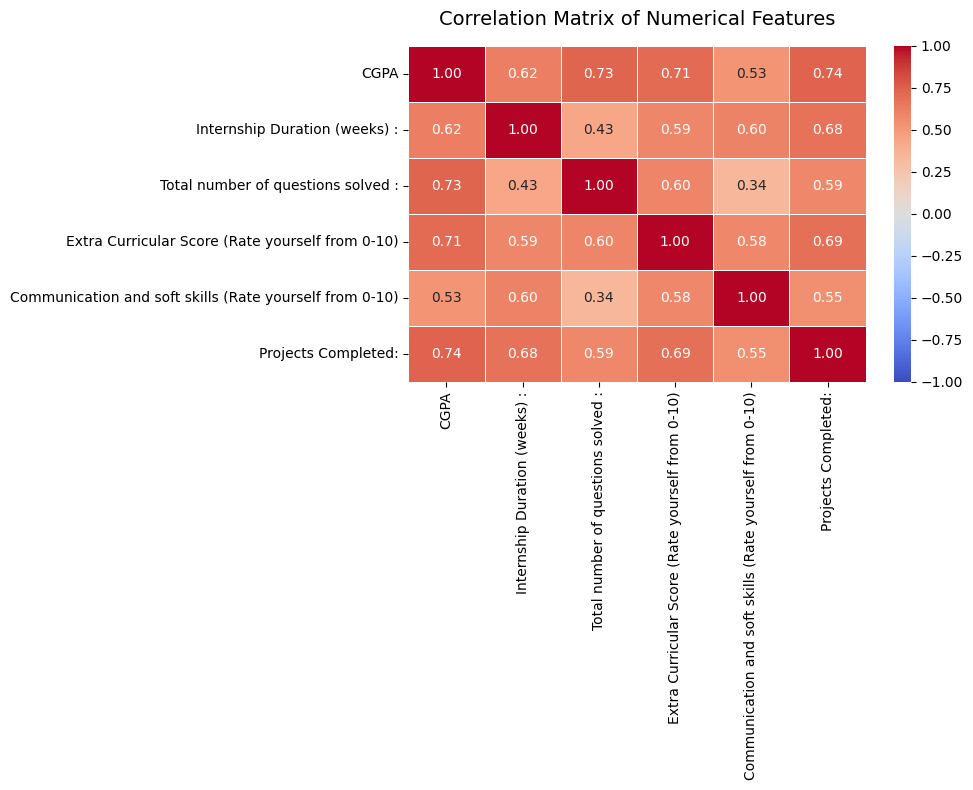

In [ ]:
# 9. Correlation Matrix Analysis
plt.figure(figsize=(10, 8))

# Select only numerical columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap using seaborn
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Matrix of Numerical Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### ML Pipeline Design

**Scaling vs. Feature Selection Order:**
We must **scale/standardize features first** before applying regularization or PCA. Regularization (like Lasso or Ridge) penalizes large coefficients, so features on larger numerical scales would be unfairly penalized if not standardized. PCA finds directions of maximum variance, which is highly skewed if features are on different scales.

**Standardization:**
Standardization (`StandardScaler`) is applied to all independent features to give them a mean of 0 and a variance of 1.

### Point 10: Define Variables and Encode Categorical Features
**Theory:** Label Encoding. Machine learning algorithms natively only understand numbers. Label Encoding converts categorical text (like 'Computer Science', 'IT') into distinct integer mappings.

**Observation:** Readies the dataset for mathematical algorithms while preserving the unique categories. Identifiers like 'Name' and 'Email' are dropped to prevent the model from memorizing individuals instead of learning patterns.

In [ ]:
# 10. Define Variables and Encode Categorical Features
from sklearn.preprocessing import LabelEncoder

# Drop identifiers and leakage columns
drop_cols = ['Email Address', 'Full Name', 'PRN ', 'If yes, Enter company/firm name and your role:']
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Define Targets
target_classification = 'Placement Status / Internship Status :'
target_regression = 'CGPA'

y_clf = df_model[target_classification] if target_classification in df_model.columns else None
y_reg = df_model[target_regression] if target_regression in df_model.columns else None

# Define Independent Features (X)
X = df_model.drop(columns=[target_classification, target_regression], errors='ignore')

# Encode Categorical features in X
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

if y_clf is not None and y_clf.dtype == 'object':
    y_clf = le.fit_transform(y_clf.astype(str))

print("Independent features (X) shape:", X.shape)


Independent features (X) shape: (132, 11)


### Point 11: Standardization
**Theory:** Feature Scaling (Z-score Normalization). Different features have vastly different scales (e.g., CGPA is 0-10, Questions Solved is 0-500+). Standardization gives every feature a mean of 0 and a standard deviation of 1.

**Observation:** Ensures that features with naturally larger numerical ranges don't unfairly dominate algorithms that rely on distance calculations (like PCA or Regularization). Every feature is put on a level playing field.

In [ ]:
# 11. Standardization
from sklearn.preprocessing import StandardScaler

# Standardization is strictly required before Regularization and PCA
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("Features standardized successfully.")


Features standardized successfully.


### Point 12: Feature Selection using Regularization
**Theory:** L1 Regularization (Lasso). An L1 penalty adds the absolute magnitude of coefficients as a penalty term to the loss function. This inherently performs feature selection by shrinking the coefficients of the least important features to exactly zero.

**Observation:** Filters out noise and redundant features, yielding a simpler, more interpretable model that is less prone to overfitting the training data.

In [ ]:
# 12. Feature Selection using Regularization (L1 / Lasso)
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.feature_selection import SelectFromModel

# For Classification (L1 Regularization penalty)
print("--- Classification Feature Selection (L1 Regularization) ---")
if y_clf is not None:
    # We use Logistic Regression with an L1 penalty to shrink less important feature coefficients to 0
    clf_selector = SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42))
    clf_selector.fit(X_scaled, y_clf)
    selected_features_clf = X.columns[clf_selector.get_support()]
    print("Selected features for Classification:", list(selected_features_clf))

# For Regression (Lasso Regularization)
print("\n--- Regression Feature Selection (Lasso) ---")
if y_reg is not None:
    # Lasso automatically performs feature selection by shrinking coefficients to 0
    reg_selector = SelectFromModel(Lasso(alpha=0.1, random_state=42))
    reg_selector.fit(X_scaled, y_reg)
    selected_features_reg = X.columns[reg_selector.get_support()]
    print("Selected features for Regression:", list(selected_features_reg))


--- Classification Feature Selection (L1 Regularization) ---
Selected features for Classification: ['Department', 'Internship Duration (weeks) :', 'LeetCode', 'HackerRank', 'CodeChef', 'CodeForces', 'Total number of questions solved :', 'Extra Curricular Score (Rate yourself from 0-10)', 'Communication and soft skills (Rate yourself from 0-10)', 'Projects Completed:']

--- Regression Feature Selection (Lasso) ---
Selected features for Regression: ['Internship Duration (weeks) :', 'LeetCode', 'CodeChef', 'Total number of questions solved :', 'Extra Curricular Score (Rate yourself from 0-10)', 'Projects Completed:']


### Point 13: Principal Component Analysis (PCA)
**Theory:** Dimensionality Reduction. PCA mathematically transforms original, potentially correlated features into a smaller number of uncorrelated variables (principal components) while retaining most of the original variance.

**Observation:** Compresses the dataset. Here, we retain enough principal components to explain 95% of the variance, simplifying the dataset's complexity while minimizing information loss.

In [ ]:
# 13. Principal Component Analysis (PCA)
from sklearn.decomposition import PCA

print("--- Principal Component Analysis (PCA) ---")
# PCA strictly requires the data to be standardized first (which we did in step 11)
pca = PCA(n_components=0.95) # Keep enough components to explain 95% of variance
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Number of PCA components needed to explain 95% variance: {pca.n_components_}")
print("Explained variance ratio by component:", [round(v, 4) for v in pca.explained_variance_ratio_])


--- Principal Component Analysis (PCA) ---
Original number of features: 11
Number of PCA components needed to explain 95% variance: 9
Explained variance ratio by component: [np.float64(0.3914), np.float64(0.1231), np.float64(0.1016), np.float64(0.0942), np.float64(0.0711), np.float64(0.0643), np.float64(0.048), np.float64(0.0314), np.float64(0.0286)]


### Point 14: Export Cleaned Dataset
**Theory:** Data Persistence. Saving the preprocessed state ensures reproducibility.

**Observation:** Allows downstream tasks (like model training or creating visualization dashboards) to start from a perfectly clean slate without needing to rerun the entire preprocessing pipeline.

In [ ]:
# Save cleaned dataset
cleaned_file = "/content/cleaned_dataset.csv"
df.to_csv(cleaned_file, index=False)

# Download it
from google.colab import files
files.download(cleaned_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df

,Department,CGPA,Internship Experience,Internship Duration (weeks) :,LeetCode,HackerRank,CodeChef,CodeForces,Total number of questions solved :,Extra Curricular Score (Rate yourself from 0-10),Communication and soft skills (Rate yourself from 0-10),Projects Completed:,Placement Status / Internship Status :,"If yes, Enter company/firm name and your role:"
0,Computer Engineering,7.97,Yes (unpaid),10.0,Yes,Yes,No,No,150.0,8.0,8,2,No,No
1,Computer Engineering,7.29,Yes (unpaid),4.0,Yes,Yes,No,No,61.0,7.0,6,5,No,No
2,Computer Engineering,8.41,Yes (unpaid),4.0,Yes,Yes,Yes,No,500.0,9.0,7,5,No,No
3,Computer Engineering,6.40,No,0.0,No,Yes,No,No,15.0,7.0,7,4,No,No
4,Computer Engineering,8.30,No,0.0,Yes,No,No,No,200.0,7.0,8,4,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Computer Engineering,8.64,Yes (paid),16.0,Yes,Yes,Yes,No,440.0,8.0,9,5,No,No
128,Information Technology,7.43,Yes (unpaid),8.0,No,Yes,Yes,No,125.0,7.0,7,3,Yes,SailPoint - Software Engineer Intern
129,Computer Engineering,8.07,No,0.0,Yes,No,Yes,No,390.0,8.0,6,4,No,No
130,Computer Engineering,8.56,Yes (paid),20.0,Yes,Yes,Yes,No,530.0,9.0,9,5,Yes,Cognizant - Software Engineer


# Assignment 2

# Histogram of CGPA

A histogram shows the distribution of the target variable and helps understand how the CGPA values are spread.

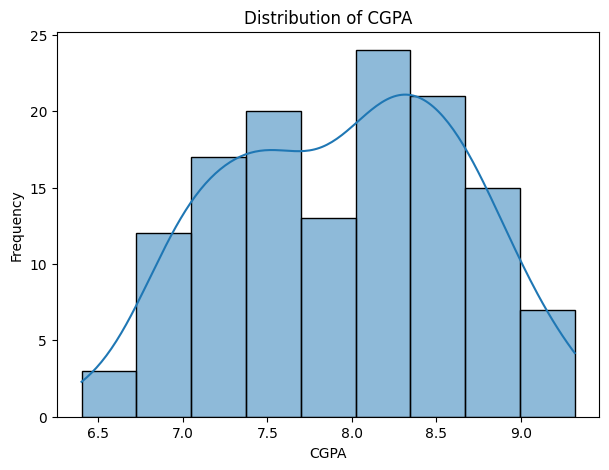

In [ ]:
# Histogram of CGPA

plt.figure(figsize=(7,5))

sns.histplot(df['CGPA'], kde=True)

plt.title('Distribution of CGPA')
plt.xlabel('CGPA')
plt.ylabel('Frequency')

plt.show()

### **Observation**

The histogram shows how the CGPA values are distributed among the students. Most students are concentrated within the middle-to-higher CGPA range, while very low or very high CGPA values occur less frequently.


### Boxplot of CGPA

A boxplot shows the median, quartiles, spread and possible outliers in the CGPA values.


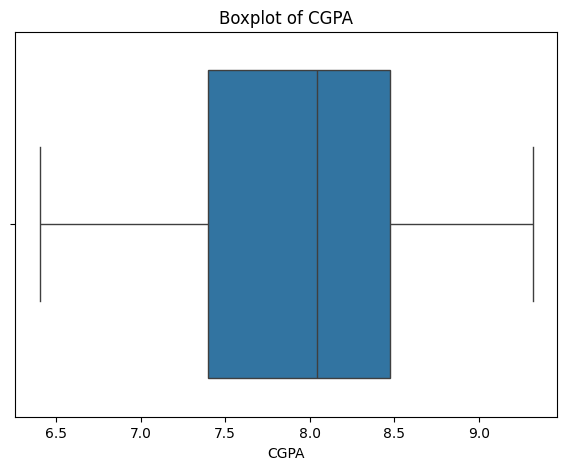

In [ ]:
# Boxplot of CGPA

plt.figure(figsize=(7,5))

sns.boxplot(x=df['CGPA'])

plt.title('Boxplot of CGPA')
plt.xlabel('CGPA')

plt.show()

### **Observation**

The boxplot shows the central tendency and spread of CGPA values. It also helps identify possible extreme values in the dataset. Since outlier treatment has already been performed during preprocessing, the CGPA values are within the treated range.


#IQR Outlier Detection
The IQR method identifies possible outliers using:

IQR=Q3−Q1

Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered possible outliers.

In [ ]:
Q1 = df['CGPA'].quantile(0.25)
Q3 = df['CGPA'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

Lower limit: 5.785
Upper limit: 10.085


#Observation
Using the IQR method, the lower limit is 5.785 and the upper limit is 10.085.

#Outlier Detection
The IQR limits are used to identify values that fall outside the normal range. Values below the lower limit or above the upper limit are considered possible outliers.

In [ ]:
outliers = df[
    (df['CGPA'] < lower) |
    (df['CGPA'] > upper)
]

print("Number of outliers:", len(outliers))

outliers

Number of outliers: 0


,Department,CGPA,Internship Experience,Internship Duration (weeks) :,LeetCode,HackerRank,CodeChef,CodeForces,Total number of questions solved :,Extra Curricular Score (Rate yourself from 0-10),Communication and soft skills (Rate yourself from 0-10),Projects Completed:,Placement Status / Internship Status :,"If yes, Enter company/firm name and your role:"


#Observation
No CGPA values fall outside the calculated IQR limits, so 0 outliers were detected.

# Train-Test Split

The train-test split divides the dataset into training and testing subsets. The training data is used to train the Linear Regression model, while the testing data is used to evaluate how well the model performs on unseen data.

Here, 80% of the data is used for training and 20% is used for testing.

In [ ]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (105, 11)
X_test shape: (27, 11)
y_train shape: (105,)
y_test shape: (27,)


#Observation
The dataset was divided into 105 training samples (80%) and 27 testing samples (20%), providing separate data for model training and evaluation.

#Feature Standardization

Standardization converts the independent variables to a common scale with a mean of 0 and standard deviation of 1. StandardScaler() is used to standardize the training and testing data.

In [ ]:
scaler = StandardScaler()

X_Scaled_train = scaler.fit_transform(X_train)
X_Scaled_test = scaler.transform(X_test)

#Observation
The features were standardized using StandardScaler, putting numerical features on a comparable scale for regression modelling.

# Linear Regression Model

Linear Regression is a supervised learning algorithm used to predict a continuous numerical target variable.

In this project, CGPA is used as the dependent variable, while the academic, internship, coding and skill-related features are used as independent variables.

The model learns the relationship between these features and CGPA from the training data.

In [ ]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print("Intercept:", linear_model.intercept_)
print("Number of coefficients:", len(linear_model.coef_))

Linear Regression model trained successfully.
Intercept: 7.946844538727691
Number of coefficients: 11


#Observation
The Linear Regression model was successfully trained using 11 features. The intercept is approximately 7.947.

# Model Prediction

After training, the `predict()` function is used to generate predicted CGPA values.

Predictions are generated for both training and testing datasets so that the model's learning ability and generalization performance can be compared.

In [ ]:
# Generate predictions

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

print("Training predictions generated:", len(y_train_pred))
print("Testing predictions generated:", len(y_test_pred))

print("\nFirst 10 Test Predictions:")
print(y_test_pred[:10])

Training predictions generated: 105
Testing predictions generated: 27

First 10 Test Predictions:
[7.43377748 7.35440678 7.82436063 9.00973182 8.68198159 8.14359134
 8.41372276 7.21453818 7.72338544 8.00417895]


#Regression Model Evaluation

Regression models can be evaluated using different performance metrics.

- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted values.
- **MSE (Mean Squared Error):** Calculates the average squared prediction error.
- **RMSE (Root Mean Squared Error):** Represents the square root of MSE and is expressed in the same unit as the target.
- **R² Score:** Represents how much variation in the target variable is explained by the model.

For MAE, MSE and RMSE, lower values indicate better performance. For R², a higher value generally indicates a better model.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("========== TRAINING RESULTS ==========")
print("MAE :", round(train_mae, 4))
print("MSE :", round(train_mse, 4))
print("RMSE:", round(train_rmse, 4))
print("R²  :", round(train_r2, 4))

print("\n========== TESTING RESULTS ==========")
print("MAE :", round(test_mae, 4))
print("MSE :", round(test_mse, 4))
print("RMSE:", round(test_rmse, 4))
print("R²  :", round(test_r2, 4))

========== TRAINING RESULTS ==========
MAE : 0.2416
MSE : 0.1071
RMSE: 0.3273
R²  : 0.7852

========== TESTING RESULTS ==========
MAE : 0.261
MSE : 0.1167
RMSE: 0.3416
R²  : 0.6797


# Adjusted R² Score

Adjusted R² is an improved version of R² that considers the number of independent features used by the regression model.

Unlike R², Adjusted R² penalizes the model when unnecessary features are added. Therefore, it is useful for evaluating multiple linear regression models.

In [ ]:
def adjusted_r2(r2, X):
    n = X.shape[0]
    p = X.shape[1]

    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))


train_adjusted_r2 = adjusted_r2(train_r2, X_train)
test_adjusted_r2 = adjusted_r2(test_r2, X_test)

print("Training Adjusted R²:", round(train_adjusted_r2, 4))
print("Testing Adjusted R² :", round(test_adjusted_r2, 4))

Training Adjusted R²: 0.7598
Testing Adjusted R² : 0.4448


#Training and Testing Fit Analysis

Training and testing performance are compared to identify possible overfitting or underfitting.

If training performance is much better than testing performance, the model may be overfitting.

If both training and testing performance are poor, the model may be underfitting.

A small difference between training and testing performance generally indicates better generalization.

In [ ]:
r2_difference = train_r2 - test_r2
rmse_difference = abs(train_rmse - test_rmse)

print("R² Difference :", round(r2_difference, 4))
print("RMSE Difference:", round(rmse_difference, 4))

if r2_difference > 0.20:
    print("Model shows signs of Overfitting.")

elif train_r2 < 0.50 and test_r2 < 0.50:
    print("Model may be Underfitting.")

else:
    print("Model is reasonably fitted.")

R² Difference : 0.1055
RMSE Difference: 0.0143
Model is reasonably fitted.


#Linear Regression – Actual vs Predicted CGPA

An Actual vs Predicted plot compares the actual CGPA values with the CGPA values predicted by the Linear Regression model.

The ideal prediction occurs when the predicted value is equal to the actual value. Therefore, points closer to the diagonal reference line indicate better predictions.

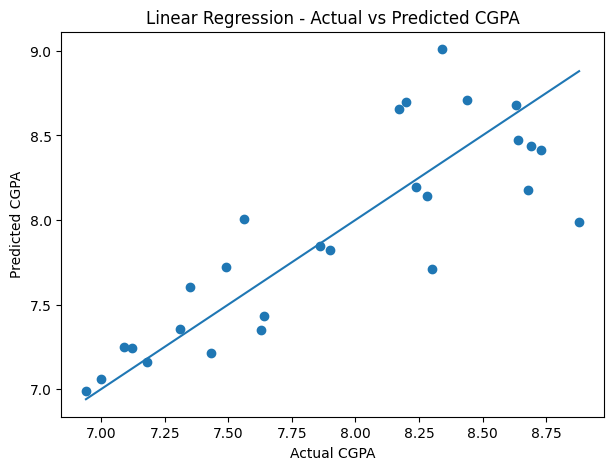

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_test_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual CGPA")
plt.ylabel("Predicted CGPA")
plt.title("Linear Regression - Actual vs Predicted CGPA")

plt.show()

#Residual Analysis

A residual is the difference between the actual target value and the predicted value.

Residual = Actual Value − Predicted Value

Residual analysis helps understand the errors made by the regression model. Positive residuals indicate under-prediction, while negative residuals indicate over-prediction.

In [ ]:
# Calculate residuals

residuals = y_test - y_test_pred

print("First 10 Residuals:")
print(residuals.head(10))

print("\nMean Residual:", round(residuals.mean(), 4))

First 10 Residuals:
56     0.206223
83    -0.044407
19     0.075639
31    -0.669732
76    -0.051982
117    0.136409
55     0.316277
128    0.215462
64    -0.233385
26    -0.444179
Name: CGPA, dtype: float64

Mean Residual: 0.0139


#Polynomial Regression

Polynomial Regression extends Linear Regression by introducing polynomial terms of the input features.

It can model non-linear relationships between independent variables and the target variable.

A polynomial degree of 2 is used in this experiment. The model is then evaluated on both training and testing data.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Create Polynomial Regression model
poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

# Train model
poly_model.fit(X_train, y_train)

# Predictions
poly_train_pred = poly_model.predict(X_train)
poly_test_pred = poly_model.predict(X_test)

# Evaluation
poly_train_rmse = np.sqrt(
    mean_squared_error(y_train, poly_train_pred)
)

poly_test_rmse = np.sqrt(
    mean_squared_error(y_test, poly_test_pred)
)

poly_train_r2 = r2_score(y_train, poly_train_pred)
poly_test_r2 = r2_score(y_test, poly_test_pred)

print("========== POLYNOMIAL REGRESSION ==========")

print("Training RMSE:", round(poly_train_rmse, 4))
print("Testing RMSE :", round(poly_test_rmse, 4))

print("Training R²:", round(poly_train_r2, 4))
print("Testing R² :", round(poly_test_r2, 4))

========== POLYNOMIAL REGRESSION ==========
Training RMSE: 0.1901
Testing RMSE : 0.8313
Training R²: 0.9275
Testing R² : -0.897


#Comparison of Linear and Polynomial Regression

Linear Regression and Polynomial Regression are compared using their training and testing performance.

RMSE measures prediction error, where a lower value is better.

R² measures the proportion of variation explained by the model, where a higher value generally indicates better performance.

The testing results are given more importance because they represent performance on unseen data.

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression"
    ],

    "Train RMSE": [
        train_rmse,
        poly_train_rmse
    ],

    "Test RMSE": [
        test_rmse,
        poly_test_rmse
    ],

    "Train R²": [
        train_r2,
        poly_train_r2
    ],

    "Test R²": [
        test_r2,
        poly_test_r2
    ]
})

comparison.round(4)

,Model,Train RMSE,Test RMSE,Train R²,Test R²
0,Linear Regression,0.3273,0.3416,0.7852,0.6797
1,Polynomial Regression,0.1901,0.8313,0.9275,-0.8970


# Assignment 3


Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

#Select Target Variable


For regression, the target variable must be continuous/numerical. We predict this value using the other relevant features.

Important: Use the same regression target that you used in our Linear Regression part of the assignment.


In [ ]:
# Display all columns
print("Available columns:")
print(df.columns.tolist())

Available columns:
['Department', 'CGPA', 'Internship Experience', 'Internship Duration (weeks) :', 'LeetCode', 'HackerRank', 'CodeChef', 'CodeForces', 'Total number of questions solved :', 'Extra Curricular Score (Rate yourself from 0-10)', 'Communication and soft skills (Rate yourself from 0-10)', 'Projects Completed:', 'Placement Status / Internship Status :', 'If yes, Enter company/firm name and your role:']


#Observation:

The dataset contains academic, internship, coding, skill-based, project, and placement-related attributes. These features provide relevant information for predicting the student's CGPA.

In [ ]:
target_column = "CGPA"

X = df.drop(columns=[target_column])
y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (132, 13)
y shape: (132,)


#Observation:

CGPA was selected as the continuous target variable for regression. The dataset contains 132 student records and 13 input features before categorical encoding.

#Convert Remaining Categorical Features


Ridge and Lasso require numerical input. If the cleaned dataset still contains categorical columns such as Department, we encode them into numerical form.

This transformation is done on a copy, so our original cleaned df is not changed.

In [ ]:
X_model = X.copy()

categorical_columns = X_model.select_dtypes(
    include=['object']
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Department', 'Internship Experience', 'LeetCode', 'HackerRank', 'CodeChef', 'CodeForces', 'Placement Status / Internship Status :', 'If yes, Enter company/firm name and your role:']


#Observation:

The remaining categorical features were identified so that they could be converted into numerical representations required by regression algorithms

In [ ]:
X_model = pd.get_dummies(
    X_model,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Final feature shape:", X_model.shape)

Final feature shape: (132, 55)


#Observation:

Categorical variables were converted into numerical dummy variables using one-hot encoding. After encoding, the feature space increased from 13 to 55 features, making the categorical information suitable for machine learning models.

#Train-Test Split

We divide the dataset into training and testing sets. The training data is used to build the model, while the testing data is used to evaluate how well the model works on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (105, 55)
Testing data: (27, 55)


#Observation:

The dataset was divided into 80% training data and 20% testing data. The training set contains 105 records, while the testing set contains 27 records. This allows the models to be evaluated on unseen data.

#Standardization

Ridge and Lasso apply penalties to model coefficients. Therefore, features should be on a similar scale. Standardization converts the features so that they have comparable scales.

We use StandardScaler inside a pipeline so that scaling is learned only from the training data.

#Linear Regression Baseline

Linear Regression is used as the baseline model. It predicts the target using a linear relationship between the input features and target.

In [ ]:
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print("Linear Regression Results")
print("----------------------------")
print("R² Score:", linear_r2)
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)

Linear Regression Results
----------------------------
R² Score: 0.6049032577688132
RMSE: 0.3793776510760689
MAE: 0.30068526152657576


#Observation:

Linear Regression achieved an R² score of 0.6049, indicating that approximately 60.49% of the variation in CGPA was explained by the input features. The RMSE was 0.3794 and MAE was 0.3007, providing a baseline for comparison with regularized models.

#Ridge Regression

Ridge Regression uses L2 regularization.

It adds a penalty based on the squared values of the coefficients. This discourages very large coefficients and helps reduce overfitting.

The main parameter is alpha:

Small alpha → weaker regularization
Large alpha → stronger regularization

In [ ]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])

ridge_params = {
    'regressor__alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Alpha:")
print(ridge_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(ridge_grid.best_score_)

Best Ridge Alpha:
{'regressor__alpha': 10}

Best Cross-Validation R²:
0.7153419376071138


#Observation:

Ridge Regression was optimized using 5-fold cross-validation. The best regularization parameter was alpha = 10, with a cross-validation R² of approximately 0.7153, indicating improved validation performance compared with the basic Linear Regression model.

#Ridge Predictions and Evaluation

We evaluate Ridge using R², RMSE and MAE.

Higher R² is better.

Lower RMSE is better.

Lower MAE is better.

In [ ]:
ridge_model = ridge_grid.best_estimator_

y_pred_ridge = ridge_model.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("----------------------------")
print("R² Score:", ridge_r2)
print("RMSE:", ridge_rmse)
print("MAE:", ridge_mae)

Ridge Regression Results
----------------------------
R² Score: 0.6600478152247666
RMSE: 0.3519078357907066
MAE: 0.2787587450501089


#Observation:

Ridge Regression achieved a testing R² of 0.6600, which is higher than Linear Regression. It also produced lower RMSE and MAE values, indicating that Ridge provided better predictive performance on the test dataset.

#Lasso Regression

Lasso Regression uses L1 regularization.

It adds a penalty based on the absolute values of the coefficients. One important advantage of Lasso is that it can reduce some coefficients exactly to zero, which can help with feature selection.

In [ ]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Lasso(max_iter=10000))
])

lasso_params = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso Alpha:")
print(lasso_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(lasso_grid.best_score_)

Best Lasso Alpha:
{'regressor__alpha': 0.01}

Best Cross-Validation R²:
0.6841352379872406


#Observation:

Lasso Regression was optimized using 5-fold cross-validation. The best alpha value was 0.01, giving a cross-validation R² of approximately 0.6841. Lasso also provides feature selection by shrinking less important coefficients toward zero.

#Lasso Predictions and Evaluation

In [ ]:
lasso_model = lasso_grid.best_estimator_

y_pred_lasso = lasso_model.predict(X_test)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Lasso Regression Results")
print("----------------------------")
print("R² Score:", lasso_r2)
print("RMSE:", lasso_rmse)
print("MAE:", lasso_mae)

Lasso Regression Results
----------------------------
R² Score: 0.6343206384855895
RMSE: 0.36498098919214345
MAE: 0.2690943354385357


#Observation:

Lasso Regression achieved a testing R² of 0.6343. Although its MAE was slightly lower than Ridge, its R² was lower and its RMSE was higher than Ridge. Therefore, Ridge provided stronger overall predictive performance based on R² and RMSE.

#Compare Linear, Ridge and Lasso

Comparing the models helps us identify which model gives the best predictive performance on the test dataset.

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],

    'R² Score': [
        linear_r2,
        ridge_r2,
        lasso_r2
    ],

    'RMSE': [
        linear_rmse,
        ridge_rmse,
        lasso_rmse
    ],

    'MAE': [
        linear_mae,
        ridge_mae,
        lasso_mae
    ]
})

results

,Model,R² Score,RMSE,MAE
0,Linear Regression,0.604903,0.379378,0.300685
1,Ridge Regression,0.660048,0.351908,0.278759
2,Lasso Regression,0.634321,0.364981,0.269094


#Observation:

Ridge Regression achieved the highest R² and the lowest RMSE among the three models, while Lasso achieved the lowest MAE. Overall, Ridge Regression provided the best balance of predictive performance for this dataset.

#Find Best Model

For regression, a model with a higher R² and lower RMSE/MAE generally performs better.

In [ ]:
best_model = results.loc[
    results['R² Score'].idxmax()
]

print("Best Model based on R²:")
print(best_model)

Best Model based on R²:
Model       Ridge Regression
R² Score            0.660048
RMSE                0.351908
MAE                 0.278759
Name: 1, dtype: object


#Observation:

Based on the highest testing R², Ridge Regression was identified as the best-performing model. It achieved an R² of 0.6600, indicating that it explains approximately 66% of the variation in CGPA.

#Ridge Actual vs Predicted Values

The actual-versus-predicted plot shows how close the model predictions are to the real target values. Points closer to the diagonal line indicate better predictions.

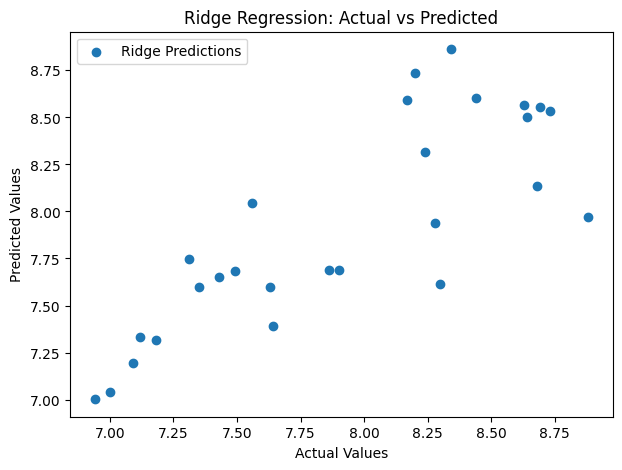

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred_ridge,
    label='Ridge Predictions'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")

plt.legend()
plt.show()

#Observation:

The Actual vs Predicted plot is used to visually evaluate Ridge Regression predictions. Points closer to the ideal diagonal relationship indicate more accurate predictions, while larger deviations represent prediction errors.

#Lasso Actual vs Predicted

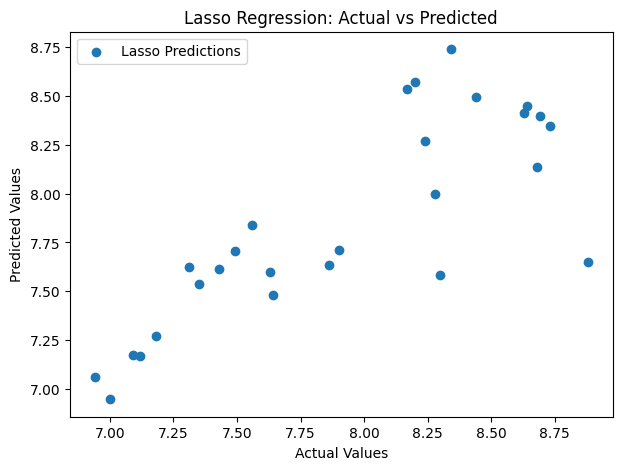

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred_lasso,
    label='Lasso Predictions'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso Regression: Actual vs Predicted")

plt.legend()
plt.show()

#Observation:

The Actual vs Predicted plot for Lasso Regression shows the relationship between the actual CGPA values and the CGPA values predicted by the model. Predictions closer to the ideal diagonal line indicate better accuracy, while deviations from the line represent prediction errors.

#Final Conclusion

In [ ]:
print("FINAL CONCLUSION")
print("----------------------------")

print("Linear Regression R² :", round(linear_r2, 4))
print("Ridge Regression R²  :", round(ridge_r2, 4))
print("Lasso Regression R²  :", round(lasso_r2, 4))

print("\nLinear Regression RMSE :", round(linear_rmse, 4))
print("Ridge Regression RMSE  :", round(ridge_rmse, 4))
print("Lasso Regression RMSE  :", round(lasso_rmse, 4))

print("\nBest model based on R²:",
      best_model['Model'])

FINAL CONCLUSION
----------------------------
Linear Regression R² : 0.6049
Ridge Regression R²  : 0.66
Lasso Regression R²  : 0.6343

Linear Regression RMSE : 0.3794
Ridge Regression RMSE  : 0.3519
Lasso Regression RMSE  : 0.365

Best model based on R²: Ridge Regression


#Conclusion:
Linear, Ridge and Lasso Regression models were applied to the cleaned dataset. Ridge Regression uses L2 regularization, while Lasso Regression uses L1 regularization. The models were compared using R², RMSE and MAE. The model having higher R² and lower error values provides better predictive performance on the test data.